# TP3 — 02: Analisis exploratorio (EDA)

**Objetivo:** entender la estructura del corpus antes de modelar: distribucion de
clases, longitud de los tweets, vocabulario caracteristico de cada polaridad y
seniales propias de Twitter (menciones, URLs, hashtags).

Todo el analisis usa el **dataset completo** (1.600.000 tweets de training y 498 de test).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

from utils import (
    cargar_training,
    cargar_test,
    limpiar_tweets,
    guardar_fig,
    etiquetas,
    TARGET,
    COLOR_NEG,
    COLOR_NEU,
    COLOR_POS,
)

# Estilo comun: ejes recesivos, sin bordes superiores/derechos, grilla suave.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
    "axes.axisbelow": True,
})

pd.set_option("display.max_colwidth", 120)

In [2]:
train = cargar_training()  # dataset completo (mandatorio)
test = cargar_test()
assert len(train) == 1_600_000 and len(test) == 498
print(f"Training: {len(train):,} tweets | Test manual: {len(test):,} tweets")

Training: 1,600,000 tweets | Test manual: 498 tweets


## Distribucion de clases

El sentimiento es una **polaridad**, por eso los colores del TP son un par divergente
(rojo = negativo, azul = positivo) con gris como punto medio neutral.

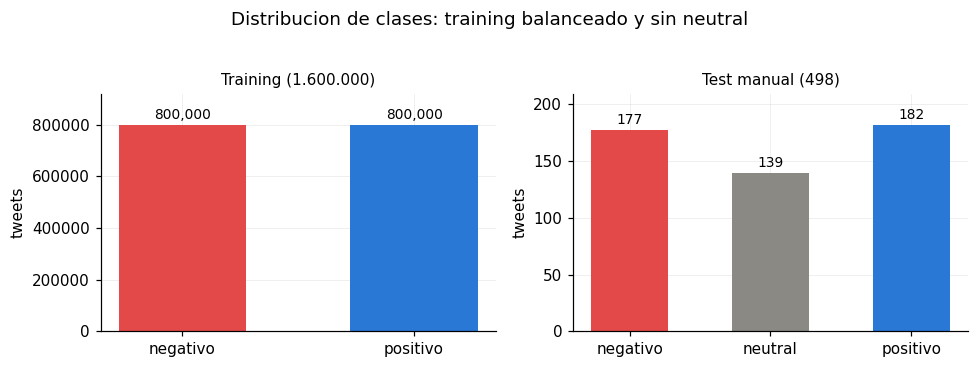

In [3]:
COLORES = {"negativo": COLOR_NEG, "neutral": COLOR_NEU, "positivo": COLOR_POS}

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, df, titulo in ((axes[0], train, "Training (1.600.000)"), (axes[1], test, "Test manual (498)")):
    d = etiquetas(df[TARGET]).value_counts().reindex(["negativo", "neutral", "positivo"]).dropna()
    barras = ax.bar(d.index, d.values, width=0.55, color=[COLORES[c] for c in d.index])
    ax.bar_label(barras, fmt="{:,.0f}", padding=2, fontsize=9)
    ax.set_title(titulo, fontsize=10)
    ax.set_ylabel("tweets")
    ax.margins(y=0.15)
fig.suptitle("Distribucion de clases: training balanceado y sin neutral", y=1.03)
fig.tight_layout()
guardar_fig(fig, "02_distribucion_clases.png")
plt.show()

El training esta perfectamente balanceado (800.000 y 800.000) y **no tiene clase
neutral**; el test manual si la tiene (139 tweets). Esto define el modelo principal
como binario.

## Longitud de los tweets

In [4]:
train["n_chars"] = train["text"].str.len()
train["n_words"] = train["text"].str.split().str.len()
train["sentimiento"] = etiquetas(train[TARGET])

resumen = train.groupby("sentimiento")[["n_chars", "n_words"]].describe(percentiles=[0.5, 0.95])
resumen.round(1)

n_chars                                        n_words        \
                count  mean   std  min   50%    95%    max     count  mean   
sentimiento                                                                  
negativo     800000.0  74.3  36.7  6.0  70.0  136.0  359.0  800000.0  13.6   
positivo     800000.0  73.9  36.1  6.0  69.0  136.0  374.0  800000.0  12.8   

                                         
             std  min   50%   95%   max  
sentimiento                              
negativo     7.1  1.0  13.0  26.0  57.0  
positivo     6.8  1.0  12.0  25.0  64.0

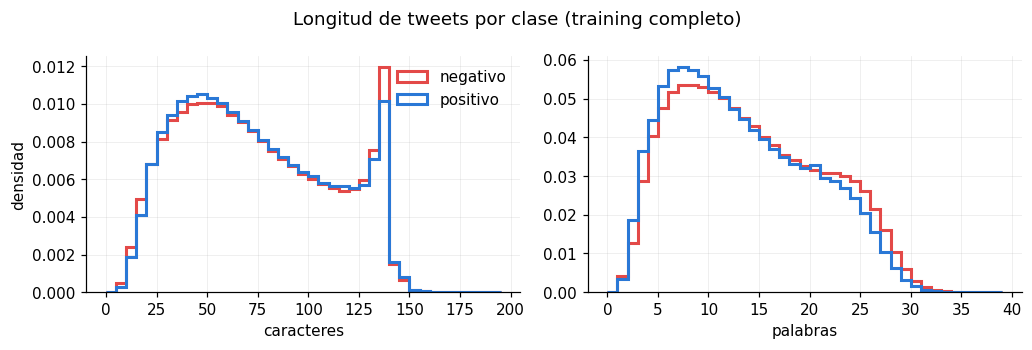

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.2))
bins_c = np.arange(0, 200, 5)
bins_w = np.arange(0, 40, 1)
for clase, color in (("negativo", COLOR_NEG), ("positivo", COLOR_POS)):
    sub = train[train["sentimiento"] == clase]
    axes[0].hist(sub["n_chars"], bins=bins_c, histtype="step", linewidth=2,
                 density=True, color=color, label=clase)
    axes[1].hist(sub["n_words"], bins=bins_w, histtype="step", linewidth=2,
                 density=True, color=color, label=clase)
axes[0].set_xlabel("caracteres"); axes[1].set_xlabel("palabras")
axes[0].set_ylabel("densidad")
axes[0].legend(frameon=False)
fig.suptitle("Longitud de tweets por clase (training completo)")
fig.tight_layout()
guardar_fig(fig, "02_longitud_tweets.png")
plt.show()

Las distribuciones de longitud de ambas clases son casi identicas (mediana ~69
caracteres, ~12 palabras): **la longitud no discrimina sentimiento**; la senial esta
en el vocabulario. El pico en 140 caracteres es el limite historico de Twitter.

## Ejemplos por clase

In [6]:
pd.set_option("display.max_colwidth", 140)
ejemplos = pd.concat([
    train[train[TARGET] == 0].sample(3, random_state=42)[["sentimiento", "text"]],
    train[train[TARGET] == 4].sample(3, random_state=42)[["sentimiento", "text"]],
])
ejemplos

,sentimiento,text
212188,negativo,@xnausikaax oh no! where did u order from? that's horrible
299036,negativo,A great hard training weekend is over. a couple days of rest and lets do it again! Lots of computer time to put in now
475978,negativo,"Right, off to work Only 5 hours to go until I'm free xD"
1012188,positivo,Is lookin 4ward to a long weekend really dont want to go to work 2day tho =[ x
1099036,positivo,#myweakness Is music and i live to meet the people who make it
1275978,positivo,figured out the Internet on my new iPod


In [7]:
test["sentimiento"] = etiquetas(test[TARGET])
test[test[TARGET] == 2].sample(3, random_state=42)[["sentimiento", "query", "text"]]

,sentimiento,query,text
483,neutral,iran,How to Track Iran with Social Media: http://bit.ly/2BoqU
232,neutral,wave sandbox,Google Wave Developer Sandbox Account Request http://bit.ly/2NYlc
157,neutral,china,myfoxdc Barrie Students Back from Trip to China: A Silver Spring high school's class trip to China has en.. http://tinyurl.com/nlhqba


## Palabras y bigramas mas frecuentes por clase

Se cuentan sobre el texto **limpio** (minusculas, URLs -> `xxurl`, menciones ->
`xxuser`, sin puntuacion) y excluyendo stopwords del ingles, para que el ranking
muestre vocabulario con contenido y no articulos/preposiciones.

Nota: las stopwords se excluyen **solo para este ranking exploratorio**. El modelo
de las notebooks 04-06 las conserva, porque negaciones como `not` son senial clave
de sentimiento.

In [8]:
train["text_clean"] = limpiar_tweets(train["text"])

# xxuser/xxurl son tokens de estructura, no vocabulario: se excluyen del ranking.
stopwords_eda = list(ENGLISH_STOP_WORDS | {"xxuser", "xxurl", "im", "amp", "quot", "just", "day", "today", "going"})


def top_terminos(textos, ngram_range, top=20):
    cv = CountVectorizer(stop_words=stopwords_eda, ngram_range=ngram_range, min_df=5)
    X = cv.fit_transform(textos)
    frec = np.asarray(X.sum(axis=0)).ravel()
    orden = frec.argsort()[::-1][:top]
    vocab = cv.get_feature_names_out()
    return pd.Series(frec[orden], index=vocab[orden])


top_uni = {
    "negativo": top_terminos(train.loc[train[TARGET] == 0, "text_clean"], (1, 1)),
    "positivo": top_terminos(train.loc[train[TARGET] == 4, "text_clean"], (1, 1)),
}

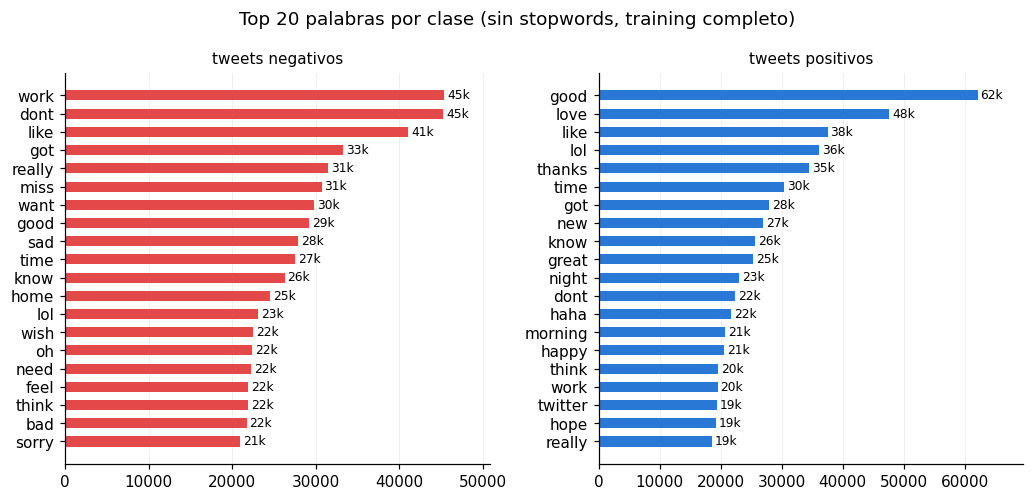

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.6))
for ax, (clase, serie) in zip(axes, top_uni.items()):
    serie = serie[::-1]
    barras = ax.barh(serie.index, serie.values, height=0.55, color=COLORES[clase])
    ax.bar_label(barras, fmt=lambda v: f"{v/1000:,.0f}k", padding=2, fontsize=8)
    ax.set_title(f"tweets {clase}s", fontsize=10)
    ax.margins(x=0.12)
    ax.grid(axis="y", alpha=0)
fig.suptitle("Top 20 palabras por clase (sin stopwords, training completo)")
fig.tight_layout()
guardar_fig(fig, "02_top_palabras.png")
plt.show()

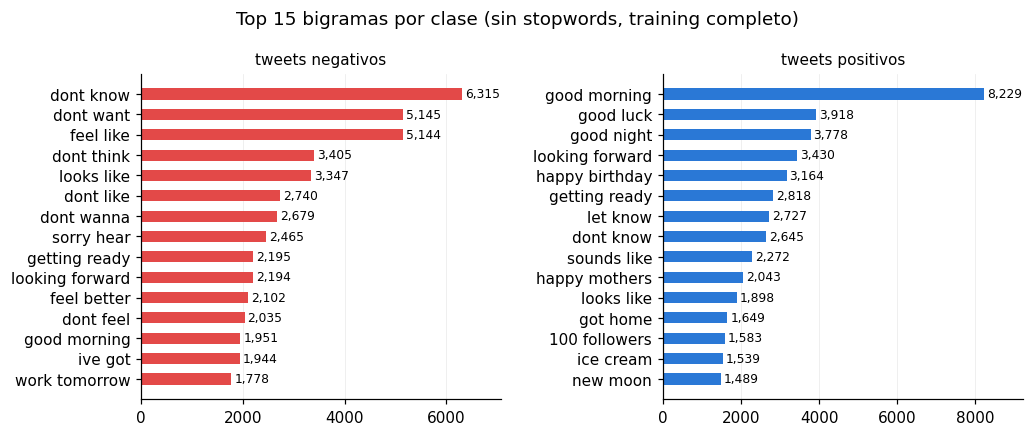

In [10]:
top_bi = {
    "negativo": top_terminos(train.loc[train[TARGET] == 0, "text_clean"], (2, 2), top=15),
    "positivo": top_terminos(train.loc[train[TARGET] == 4, "text_clean"], (2, 2), top=15),
}

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, (clase, serie) in zip(axes, top_bi.items()):
    serie = serie[::-1]
    barras = ax.barh(serie.index, serie.values, height=0.55, color=COLORES[clase])
    ax.bar_label(barras, fmt="{:,.0f}", padding=2, fontsize=8)
    ax.set_title(f"tweets {clase}s", fontsize=10)
    ax.margins(x=0.12)
    ax.grid(axis="y", alpha=0)
fig.suptitle("Top 15 bigramas por clase (sin stopwords, training completo)")
fig.tight_layout()
guardar_fig(fig, "02_top_bigramas.png")
plt.show()

## Seniales propias de Twitter

Frecuencia de menciones, URLs, hashtags y signos expresivos por clase, medida sobre
el texto **original** (antes de limpiar).

In [11]:
seniales = pd.DataFrame({
    "mencion @":    train["text"].str.contains(r"@\w+", regex=True),
    "URL":          train["text"].str.contains(r"https?://|www\.", regex=True),
    "hashtag #":    train["text"].str.contains(r"#\w+", regex=True),
    "exclamacion !": train["text"].str.contains("!", regex=False),
    "pregunta ?":   train["text"].str.contains(r"\?", regex=True),
    "sentimiento":  train["sentimiento"],
})
tabla_seniales = seniales.groupby("sentimiento").mean().T.mul(100).round(1)
tabla_seniales.columns = [f"% en {c}s" for c in tabla_seniales.columns]
tabla_seniales

,% en negativos,% en positivos
mencion @,37.6,54.7
URL,3.2,6.4
hashtag #,1.9,2.6
exclamacion !,24.8,35.4
pregunta ?,10.2,10.8


## Hallazgos del EDA

1. **Balance perfecto** 50/50 en training; no hay que corregir desbalance.
2. **La longitud no discrimina**: ambas clases tienen la misma distribucion; la senial
   esta en el vocabulario.
3. **Vocabulario claramente diferenciado**: `work`, `miss`, `sad`, `sick`, `hate` en
   negativos vs `good`, `love`, `thanks`, `lol`, `happy` en positivos. Un modelo lineal
   sobre TF-IDF tiene mucha senial para aprender.
4. **Bigramas** ya muestran contexto util (`cant wait`, `feel better`, `mothers day`,
   `good morning`), lo que justifica probar `ngram_range=(1,2)` en la vectorizacion.
5. **Menciones en ~46%** de los tweets: se conservan como token `xxuser` (senial de
   interaccion) sin retener el usuario puntual.
6. Los signos de exclamacion aparecen algo mas en positivos; las preguntas, algo mas
   en negativos. Son seniales debiles pero coherentes.